# Modelos Multimodales
### Máster en IA y Computación Cuántica Aplicada a los Mercados Financieros (MIAX)

---

- **Autor:** Pablo Hernández Cámara
- **Contacto:** [pablo.hernandez-camara@uv.es](mailto:pablo.hernandez-camara@uv.es)
- **Notebook:** Generación de video con StableDiffusionVideo

Usaremos tres componentes principales:

- `diffusers`: pipelines y modelos de difusión.
- `transformers`: componentes de modelos utilizados por el ecosistema de Hugging Face.
- `accelerate`: utilidades para ejecutar modelos de forma más eficiente, incluyendo estrategias de gestión de memoria.

In [1]:
!pip install -q -U diffusers transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 55.7 MB/s eta 0:00:00


## Cargar Stable Video Diffusion

Vamos a utilizar el checkpoint: `stabilityai/stable-video-diffusion-img2vid-xt`

El pipeline `StableVideoDiffusionPipeline` recibe una imagen y genera una secuencia de fotogramas.

Algunos detalles importantes:

- **`torch_dtype=torch.float16`**  
Utiliza precisión de 16 bits, reduciendo el consumo de memoria frente a `float32`.

- **`variant="fp16"`**  
Indica que queremos utilizar la variante del modelo preparada para `float16`.

- **`enable_model_cpu_offload()`**  
Permite mover componentes del modelo entre CPU y GPU para reducir el consumo de memoria de la GPU. Puede ser especialmente útil en entornos como Google Colab.


In [2]:
import torch
from diffusers import StableVideoDiffusionPipeline
from diffusers.utils import load_image, export_to_video

pipe = StableVideoDiffusionPipeline.from_pretrained("stabilityai/stable-video-diffusion-img2vid-xt", torch_dtype=torch.float16, variant="fp16")
pipe.enable_model_cpu_offload()

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/496 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 9 files:   0%|          | 0/9 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/520 [00:00<?, ?it/s]

El punto de partida es una imagen estática.

En este ejemplo utilizaremos una imagen de muestra proporcionada en Hugging Face. La redimensionamos a **1024 × 576 píxeles**, una relación de aspecto panorámica adecuada para este experimento.


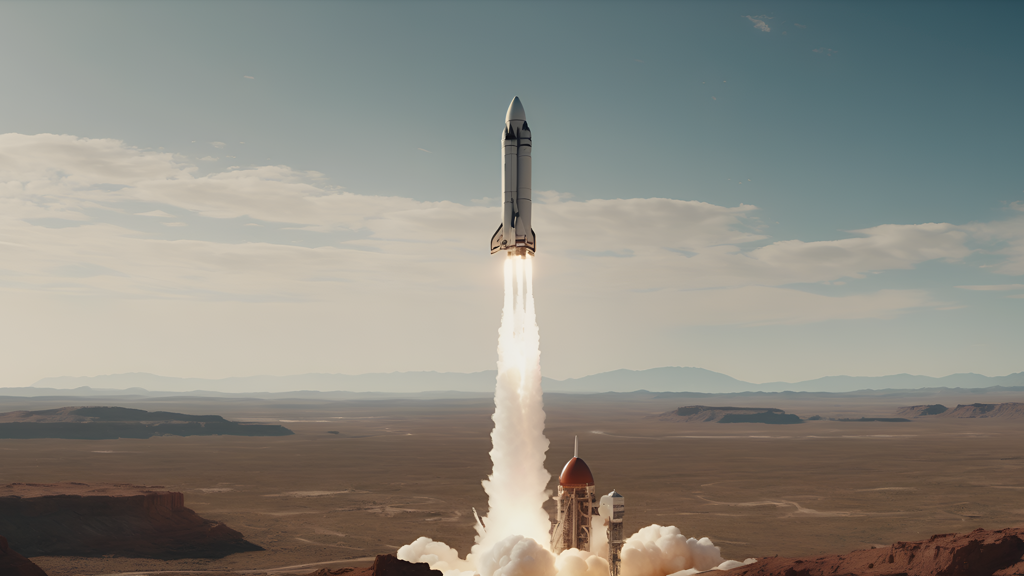

In [3]:
image = load_image("https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/svd/rocket.png")
image = image.resize((1024, 576))
image

Ahora llega la parte fundamental:

```text
Imagen inicial
      ↓
Stable Video Diffusion
      ↓
Fotogramas (frames)
      ↓
Archivo de vídeo
```

La salida intermedia no es todavía un `.mp4`. El modelo produce una **secuencia de imágenes**, almacenada en `frames`.

Usamos una semilla para hacer el experimento más reproducible. Si ejecutamos de nuevo el mismo proceso con las mismas condiciones, la aleatoriedad inicial queda controlada.

Los fotogramas necesitan memoria para ser decodificados. `decode_chunk_size=8` permite procesarlos en pequeños bloques, ayudando a controlar el consumo de memoria. En generación de vídeo, la memoria puede convertirse rápidamente en una limitación porque estamos trabajando con **muchas imágenes**, no con una sola.

In [4]:
generator = torch.manual_seed(42)
frames = pipe(image, decode_chunk_size=8, generator=generator).frames[0]

There are modules in AutoencoderKLTemporalDecoder that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKLTemporalDecoder that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


  0%|          | 0/25 [00:00<?, ?it/s]

There are modules in AutoencoderKLTemporalDecoder that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


In [5]:
print(len(frames), frames[0].size)

25 (1024, 576)


Ya tenemos los `frames`. El siguiente paso es empaquetarlos en un archivo de vídeo. `fps=12` significa que reproduciremos **12 fotogramas por segundo** y el resultado se guardará como `generated.mp4`.

In [6]:
export_to_video(frames, "generated.mp4", fps=12)

'generated.mp4'

Si estamos trabajando en Google Colab o Jupyter, podemos incrustar el archivo generado en la salida.

In [7]:
from IPython.display import Video, display

display(Video("generated.mp4", embed=True))

Prueba a partir de otra imagen inicial, a ver que videos genera.

- ¿Qué elementos de la imagen parecen mantenerse?
- ¿Qué elementos empiezan a moverse?
- ¿El movimiento resulta físicamente plausible?
- ¿Qué ocurre con zonas pequeñas o poco definidas?
- ¿El modelo puede inventar movimiento que no estaba implícito en la imagen?

**Importante:** el modelo tiene que inferir el movimiento a partir de una única imagen. Por tanto, no debemos interpretar el resultado como una simulación física exacta de lo que realmente ocurriría. Por esto, hoy en dia hay muchisima investigación en los modelos de video, ya que a partir de videos estos modelos estan aprendiendo las leyes de la física.